Restarted Python 3.11.9

# Simulating a confined LJ fluid with Jax MD

## Simulation Set Up

In [14]:
import jax.numpy as jnp
from jax import random, jit
from matplotlib import pyplot as plt
import matplotlib.animation as animation
import numpy as np
from jax_md import space, energy, simulate, quantity
from tqdm.notebook import tqdm
from jax.scipy.special import gamma  



## Simulate in 2d for ease

In [15]:
# Parameters
num_realizations=10
num_steps = 5000
num_bins = 50
dt = 1e-3
sigma = 1.0
epsilon = 1.0
kT = 1
Nx = 12
spacing = 1.1 * sigma
side_length = Nx * spacing
dim=2
num_particles=Nx**dim
density=num_particles/side_length**dim
num_bins_gr = 100
box_vol = side_length**dim  
sigma_wall=1
epsilon_wall=1
num_steps_equilibrium=2000


In [16]:
#Grid set up for density field and radial distribution function
#density
bin_width = side_length / num_bins
grid_edges = jnp.linspace(0, side_length, num_bins + 1)  # Bin edges
grid_centers = 0.5 * (grid_edges[:-1] + grid_edges[1:])  # Grid center points
rho_ensemble_avg = jnp.zeros((num_realizations, num_steps_equilibrium) + (num_bins,) * dim)

#g(r)
r_max = side_length / 2  # Maximum distance for g(r) (half the box size)
dr = r_max / num_bins_gr  # Bin width for g(r)
r_bins = jnp.linspace(0, r_max, num_bins_gr + 1)  # Bin edges for g(r)
r_centers = 0.5 * (r_bins[:-1] + r_bins[1:])  # Bin centers for g(r)
gr_ensemble_avg = jnp.zeros((num_realizations, num_steps_equilibrium, num_bins_gr))  # Store g(r)



In [17]:
# Initial positions
base_R = np.stack([np.array(r) for r in np.ndindex((Nx,)*dim)]) * spacing
max_offset = (spacing - sigma) / 2

# Periodic space
displacement, shift = space.periodic(side_length)

# Use map_product to compute pairwise displacements
pair_displacement = space.map_product(displacement)


## LJ fluid with external LJ 9 3 potential at either end of box in x direction to mimic wall interactions

In [18]:
energy_fn = energy.lennard_jones_pair(displacement, sigma=sigma, epsilon=epsilon, r_cutoff=2.5 * sigma)
energy_fn = jit(energy_fn)

def LJ_93_potential(x,sigma,epsilon,rho,x_c):
    return 4*jnp.pi*sigma*epsilon*rho*((1/45)*(sigma/(x+x_c))**9-(1/6)*(sigma/(x+x_c))**3)

# Wall potential
def wall_potential(R):
    x = R[:, 0]
    return LJ_93_potential(x,sigma_wall,epsilon_wall,1,0.5*sigma)+LJ_93_potential(side_length-x,sigma_wall,epsilon_wall,1,0.5*sigma)

def total_energy_fn(R):
    """Total energy = interparticle energy + external potential energy summed over all particles"""
    return energy_fn(R) + jnp.sum(wall_potential(R))

In [19]:
# NVT simulation
init_fn, apply_fn = simulate.nvt_langevin(total_energy_fn, shift, dt=dt, kT=kT)
apply_fn = jit(apply_fn)

In [20]:
def compute_gr(positions, pair_displacement, r_bins, density, num_particles, dim):
    """
    Compute the radial distribution function g(r) for arbitrary dimensions.
    
    Args:
        positions: Array of shape (N, dim) containing particle positions.
        pair_displacement: Function to compute pairwise displacements.
        r_bins: Array of bin edges for the histogram.
        density: Number density of the system (particles per unit volume/area).
        num_particles: Number of particles.
        box_area: Total volume/area of the simulation box (used for reference).
        dim: Integer representing the dimensionality of the system.
    
    Returns:
        gr: Radial distribution function g(r) as a function of r.
    """
    # Compute pairwise distances
    dr = pair_displacement(positions, positions)  # Shape: (N, N, dim)
    r = jnp.sqrt(jnp.sum(dr**2, axis=-1))  # Shape: (N, N)

    # Exclude self-interactions (diagonal elements where i == j)
    r = r.at[jnp.diag_indices(num_particles)].set(jnp.inf)  # Set self-distances to inf to exclude them

    # Flatten the distance array and histogram
    r_flat = r.flatten()
    hist, _ = jnp.histogram(r_flat, bins=r_bins)

    # Normalize to get g(r)
    r_edges = r_bins
    r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
    dr = r_edges[1] - r_edges[0]

    # Compute the surface area of a d-dimensional hyperspherical shell
    # Surface area factor: 2 * pi^(d/2) / Gamma(d/2)
    surface_factor = 2 * jnp.power(jnp.pi, dim / 2) / gamma(dim / 2)
    shell_volume = surface_factor * jnp.power(r_centers, dim - 1) * dr  # d-dimensional shell volume

    # Number of unique pairs
    num_pairs = num_particles * (num_particles - 1) / 2

    # Expected number of pairs in each shell for a uniform system
    # For a uniform density, the number of pairs in a shell is density * shell_volume * num_particles,
    # but we normalize by the total number of pairs to get g(r)
    expected_pairs = density * shell_volume * num_particles  # Average number of pairs per shell

    # Compute g(r) by normalizing the histogram
    gr = hist / expected_pairs

    # Ensure g(r) is not negative and handle edge cases
    gr = jnp.where(r_centers > 0, gr, 0.0)
    gr = jnp.maximum(gr, 0.0)

    return gr


## Simulate over a number of realizations and time steps

In [21]:
for realization in tqdm(range(num_realizations)):
    key = random.PRNGKey(realization)  # Different seed for each realization
    random_offset = np.random.uniform(-max_offset, max_offset, size=(Nx**dim, dim))
    R = jnp.array(base_R + random_offset)
    state = init_fn(key, R)
    for t in range(num_steps):
        state = apply_fn(state)
        R_t = state.position
        if t>=(num_steps-num_steps_equilibrium):
            t=t-(num_steps-num_steps_equilibrium)
            
            # Compute density field
            indices = ((R_t / side_length) * num_bins).astype(int)
            indices = jnp.minimum(indices, num_bins - 1)  # Keep indices within range
            # Create density field for this time step (for this realization)
            rho_realization_t = jnp.zeros((num_bins,) * dim)
            # Count particles per grid cell
            rho_realization_t = rho_realization_t.at[tuple(indices.T)].add(1)
            # Normalize by grid volume
            rho_realization_t /= bin_width**dim  # Normalize by the volume of each grid cell
            # Store the density field for this realization and time step
            rho_ensemble_avg = rho_ensemble_avg.at[realization, t].set(rho_realization_t)
            # Compute g(r)
            gr_t = compute_gr(R_t, pair_displacement, r_bins, density, num_particles, dim)
            gr_ensemble_avg = gr_ensemble_avg.at[realization, t].set(gr_t)




# Compute ensemble average for density and g(r)
rho_ensemble_avg_time = jnp.mean(rho_ensemble_avg, axis=0)  # Average over realizations
gr_ensemble_avg_time = jnp.mean(gr_ensemble_avg, axis=0)  # Average over realizations for g(r)


  0%|          | 0/10 [00:00<?, ?it/s]

c:\Users\tkay\AppData\Local\Programs\Python\Python311\Lib\site-packages\jax\_src\numpy\reductions.py:233: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in sum is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return _reduction(a, "sum", lax.add, 0, preproc=_cast_to_numeric,


## Plot results

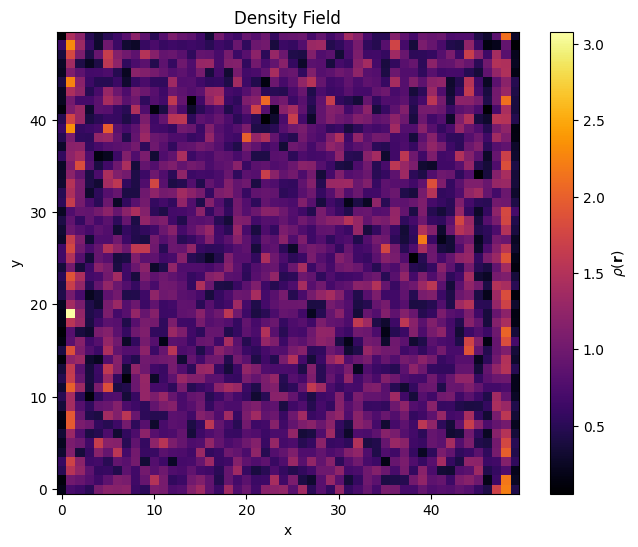

In [22]:
# Plot density
# averaged over time after equilibration
plt.figure(figsize=(8, 6))
plt.imshow(jnp.mean(rho_ensemble_avg_time,axis=tuple(x for x in range(0, dim + 1) if x != 1 and x != 2)).T, origin='lower', cmap='inferno')
plt.colorbar(label=r'$ \rho(\mathbf{r}) $')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Density Field')
plt.show()


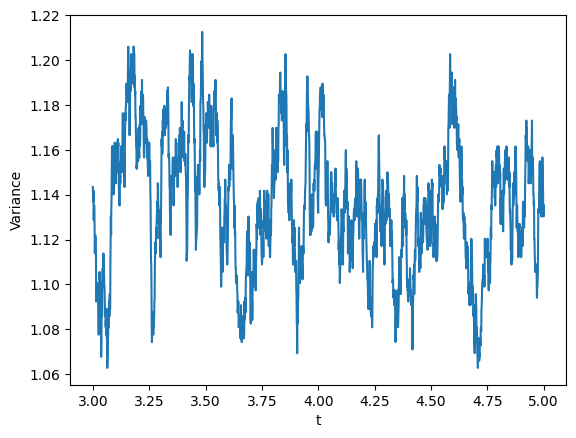

In [23]:
# Plot variance after equilibration
plt.plot(np.linspace((num_steps-num_steps_equilibrium)*dt,num_steps*dt,num_steps_equilibrium),jnp.var(rho_ensemble_avg_time,axis=tuple(range(1,dim+1))))
plt.xlabel('t')
plt.ylabel('Variance')
plt.show()



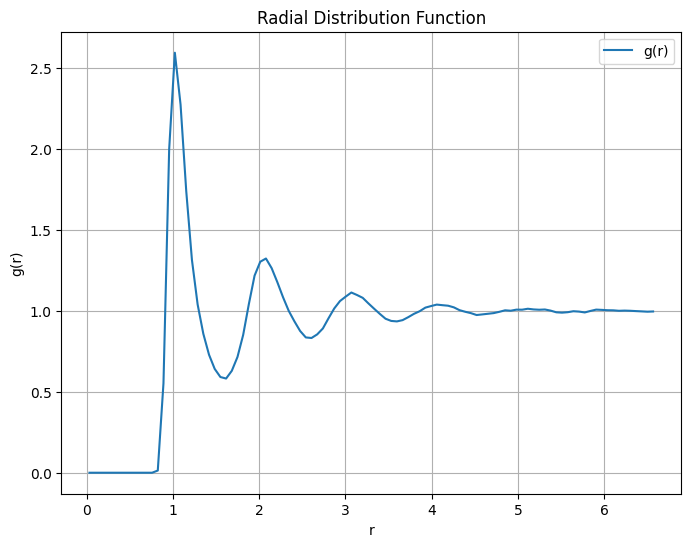

In [24]:
# Plot g(r) averaged after equilibration
gr_avg = jnp.mean(gr_ensemble_avg_time[-num_steps_equilibrium:], axis=0)  # Average over last 100 time steps
plt.figure(figsize=(8, 6))
plt.plot(r_centers, gr_avg, label='g(r)')
plt.xlabel('r')
plt.ylabel('g(r)')
plt.title('Radial Distribution Function')
plt.grid()
plt.legend()
plt.show()



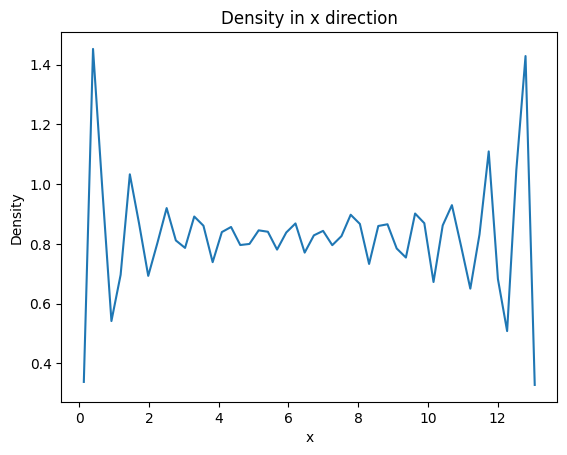

In [25]:
# Plot x profile of density
plt.plot(grid_centers,jnp.mean(rho_ensemble_avg_time[-num_steps_equilibrium:],axis=tuple(x for x in range(0, dim + 1) if x != 1)))#average over time after equilibration
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Density in x direction')
plt.show()
